In [1]:
import torch
import torch.nn as nn

import pandas as pd
import numpy as np

import inspect
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

c:\Users\kakas\Documents\Projects\wqm_final\WQM_AI


In [2]:
df = pd.read_csv("../dataset/generated/water_quality_dataset.csv")

df.head()

,Timestamp,pH,Temperature,Dissolved_Oxygen,Turbidity,Water_Quality
0,2026-01-01 00:00:00,7.21,26.90,8.21,24783.23,Good
1,2026-01-01 00:00:05,7.22,26.63,8.20,8674.25,Good
2,2026-01-01 00:00:10,7.21,26.85,8.19,3035.97,Good
3,2026-01-01 00:00:15,7.22,27.17,8.18,1062.35,Good
4,2026-01-01 00:00:20,7.19,27.07,8.17,371.82,Good


In [3]:
df["Water_Quality"] = df["Water_Quality"].map({

    "Good":1,

    "Bad":0

})

In [4]:
X = df[

    [

        "pH",

        "Temperature",

        "Dissolved_Oxygen",

        "Turbidity"

    ]

].values

y = df["Water_Quality"].values

In [5]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [6]:
def create_sequences(X, y, sequence_length=10):

    X_seq = []
    y_seq = []

    for i in range(len(X) - sequence_length):

        X_seq.append(X[i:i+sequence_length])

        y_seq.append(y[i+sequence_length])

    return np.array(X_seq), np.array(y_seq)

In [7]:
SEQUENCE_LENGTH = 10

X, y = create_sequences(
    X,
    y,
    sequence_length=SEQUENCE_LENGTH
)

In [8]:
print(X.shape)
print(y.shape)

(99990, 10, 4)
(99990,)


In [9]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    shuffle=True

)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1).to(device)

Using Device: cuda


In [11]:
import torch.optim as optim

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

from src.model.nflnn import NFLNN
from src.model.trainer import Trainer

In [12]:
train_dataset = TensorDataset(
    X_train,
    y_train
)

test_dataset = TensorDataset(
    X_test,
    y_test
)

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [14]:
model = NFLNN().to(device)

print(model)

NFLNN(
  (membership): GaussianMembership()
  (rules): FuzzyRuleLayer(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (rule_generator): Sequential(
      (0): Linear(in_features=12, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=32, bias=True)
      (3): ReLU()
    )
  )
  (liquid): LiquidCell(
    (input_layer): Linear(in_features=32, out_features=32, bias=True)
    (hidden_layer): Linear(in_features=32, out_features=32, bias=True)
    (tau_layer): Linear(in_features=32, out_features=32, bias=True)
    (activation): Tanh()
  )
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


In [15]:
criterion = nn.BCELoss()

In [16]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [17]:
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

In [18]:
OUTPUT_DIR = "outputs"

MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
LOG_DIR = os.path.join(OUTPUT_DIR, "logs")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")

for folder in [MODEL_DIR, LOG_DIR, PLOT_DIR, REPORT_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Output folders created successfully.")

Output folders created successfully.


In [19]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}

In [20]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: torch.Size([79992, 10, 4])
y_train shape: torch.Size([79992, 1])


In [21]:
x, y = next(iter(train_loader))

print("Batch X shape:", x.shape)
print("Batch y shape:", y.shape)

print(inspect.getsource(NFLNN.forward))

Batch X shape: torch.Size([64, 10, 4])
Batch y shape: torch.Size([64, 1])
    def forward(self, x):

        batch_size = x.size(0)

        h = torch.zeros(
            batch_size,
            self.liquid.hidden_dim,
            device=x.device 
        )

        sequence_length = x.size(1)

        for t in range(sequence_length):

            xt = x[:, t, :]

            memberships = self.membership(xt)

            rules = self.rules(memberships)

            h = self.liquid(
                rules,
                h)

        output = self.classifier(h)

        return output



In [22]:
output = model(x.to(device))

print("Model Output Shape:", output.shape)

Model Output Shape: torch.Size([64, 1])


In [23]:
EPOCHS = 30

for epoch in range(EPOCHS):

    train_loss, train_acc = trainer.train_epoch(train_loader)
    test_loss, test_acc = trainer.evaluate(test_loader)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Test Loss: {test_loss:.4f} "
        f"| Test Acc: {test_acc:.4f}"
    )

Epoch [1/30] | Train Loss: 0.2093 | Train Acc: 0.8854 | Test Loss: 0.1932 | Test Acc: 0.8868
Epoch [2/30] | Train Loss: 0.1799 | Train Acc: 0.9078 | Test Loss: 0.0812 | Test Acc: 0.9901
Epoch [3/30] | Train Loss: 0.0367 | Train Acc: 0.9931 | Test Loss: 0.0312 | Test Acc: 0.9936
Epoch [4/30] | Train Loss: 0.0291 | Train Acc: 0.9935 | Test Loss: 0.0278 | Test Acc: 0.9940
Epoch [5/30] | Train Loss: 0.0272 | Train Acc: 0.9939 | Test Loss: 0.0277 | Test Acc: 0.9936
Epoch [6/30] | Train Loss: 0.0260 | Train Acc: 0.9941 | Test Loss: 0.0251 | Test Acc: 0.9940
Epoch [7/30] | Train Loss: 0.0249 | Train Acc: 0.9940 | Test Loss: 0.0258 | Test Acc: 0.9939
Epoch [8/30] | Train Loss: 0.0237 | Train Acc: 0.9945 | Test Loss: 0.0248 | Test Acc: 0.9939
Epoch [9/30] | Train Loss: 0.0209 | Train Acc: 0.9951 | Test Loss: 0.0424 | Test Acc: 0.9949
Epoch [10/30] | Train Loss: 0.0328 | Train Acc: 0.9947 | Test Loss: 0.0180 | Test Acc: 0.9952
Epoch [11/30] | Train Loss: 0.1761 | Train Acc: 0.9942 | Test Loss: 0

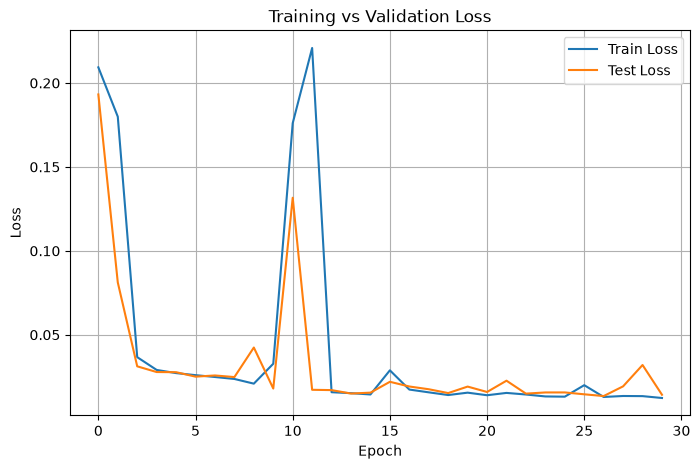

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.savefig("outputs/plots/loss_curve.png", dpi=300)

plt.show()

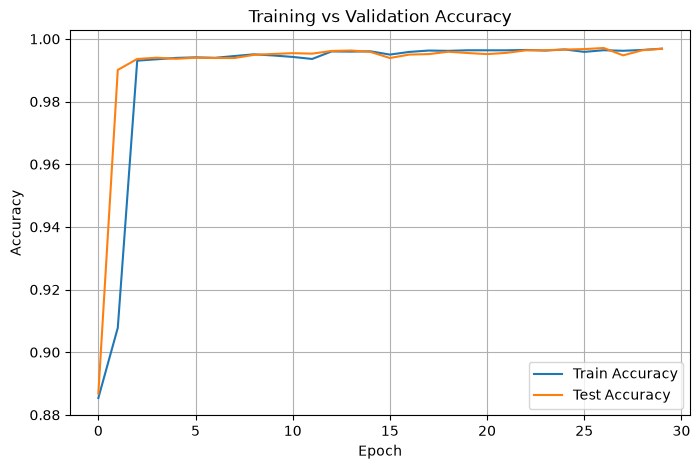

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history["train_accuracy"], label="Train Accuracy")
plt.plot(history["test_accuracy"], label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.savefig("outputs/plots/accuracy_curve.png", dpi=300)

plt.show()

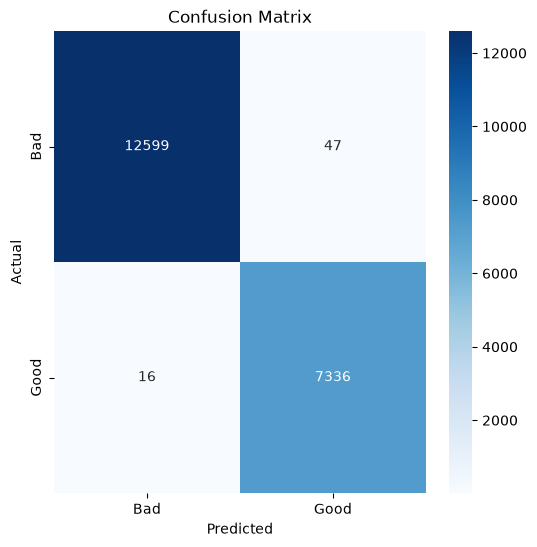

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()

predictions = []
actual = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        output = model(x)

        preds = (output >= 0.5).float()

        predictions.extend(preds.cpu().numpy())

        actual.extend(y.cpu().numpy())

cm = confusion_matrix(actual, predictions)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=["Bad","Good"],
    yticklabels=["Bad","Good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig("outputs/plots/confusion_matrix.png", dpi=300)

plt.show()

In [27]:
from sklearn.metrics import classification_report

report = classification_report(
    actual,
    predictions,
    target_names=["Bad","Good"]
)

print(report)

with open(
    "outputs/reports/classification_report.txt",
    "w"
) as f:

    f.write(report)

              precision    recall  f1-score   support

         Bad       1.00      1.00      1.00     12646
        Good       0.99      1.00      1.00      7352

    accuracy                           1.00     19998
   macro avg       1.00      1.00      1.00     19998
weighted avg       1.00      1.00      1.00     19998



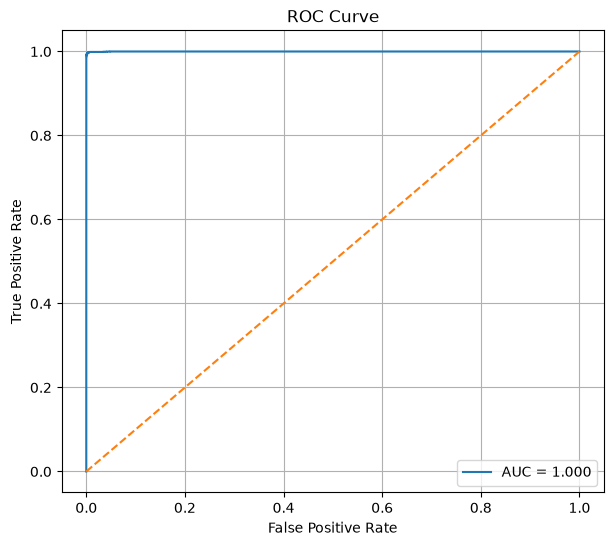

In [28]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

probs = []

actual = []

model.eval()

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(device)

        output = model(x)

        probs.extend(output.cpu().numpy())

        actual.extend(y.cpu().numpy())

fpr,tpr,_ = roc_curve(actual, probs)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.savefig("outputs/plots/roc_curve.png", dpi=300)

plt.show()

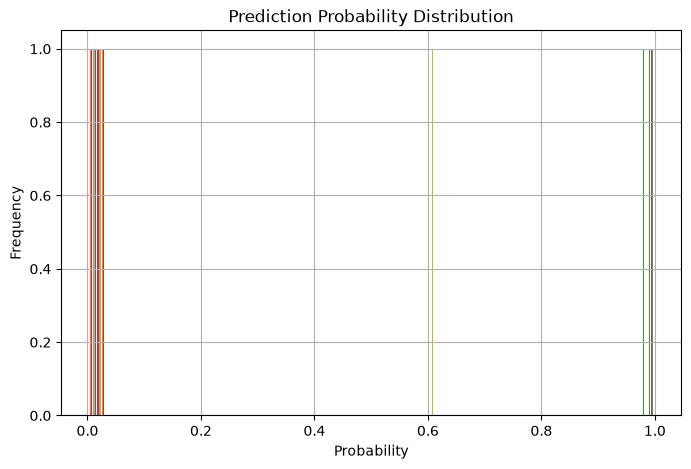

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    probs,
    bins=30
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Probability")

plt.ylabel("Frequency")

plt.grid()

plt.savefig(
    "outputs/plots/prediction_distribution.png",
    dpi=300
)

plt.show()

In [30]:
print(model)

with open(
    "outputs/reports/model_summary.txt",
    "w"
) as f:

    f.write(str(model))

NFLNN(
  (membership): GaussianMembership()
  (rules): FuzzyRuleLayer(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (rule_generator): Sequential(
      (0): Linear(in_features=12, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=32, bias=True)
      (3): ReLU()
    )
  )
  (liquid): LiquidCell(
    (input_layer): Linear(in_features=32, out_features=32, bias=True)
    (hidden_layer): Linear(in_features=32, out_features=32, bias=True)
    (tau_layer): Linear(in_features=32, out_features=32, bias=True)
    (activation): Tanh()
  )
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


In [31]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    os.path.join(LOG_DIR, "training_history.csv"),
    index=False
)

print("Training history saved.")

Training history saved.


In [32]:
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": 4,
    "hidden_dim": 32,
    "num_memberships": 3,
}, "best_model.pth")

joblib.dump(scaler,os.path.join(MODEL_DIR, "scaler.pkl"))

print("Model and Scalar Exported sucessfully.")

Model and Scalar Exported sucessfully.
